# Supplier Performance Analysis

Scoring and ranking supplier reliability using delivery performance data. Since the DataCo dataset lacks explicit supplier IDs, we use **order origin (city)** as a supplier proxy location and group by **origin × product** as a supplier-product combination.

**Hypothesis tested:** H3 — 20% of suppliers cause 80% of delays (Pareto)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

VISUALS_DIR = Path('../visuals')
VISUALS_DIR.mkdir(exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(VISUALS_DIR / f'{name}.png', dpi=150, bbox_inches='tight')


In [2]:
df = pd.read_csv('../data/supply_chain_cleaned.csv')
print(f'Shape: {df.shape}')
df.head(2)


Shape: (180519, 62)


,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,customer_country,customer_fname,customer_id,customer_lname,customer_segment,customer_state,customer_street,customer_zipcode,department_id,department_name,latitude,longitude,market,order_city,order_country,order_customer_id,order_date_dateorders,order_id,order_item_cardprod_id,order_item_discount,order_item_discount_rate,order_item_id,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total,order_profit_per_order,order_region,order_state,order_status,product_card_id,product_category_id,product_image,product_name,product_price,product_status,shipping_date_dateorders,shipping_mode,order_year,order_month,order_day,order_dayofweek,order_quarter,order_hour,is_weekend,shipping_year,shipping_month,actual_shipping_delay,is_early_or_ontime,order_to_shipping_hours,order_season
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,Cally,20755,Holloway,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,2018,1,31,2,1,22,0,2018,2,-1.00,1,72.00,Winter
1,TRANSFER,5,4,-79.70,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,Irene,19492,Luna,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-79.70,South Asia,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,2018,1,13,5,1,12,1,2018,1,1.00,0,120.00,Winter


In [3]:
# === Create Supplier Proxy ===
df['supplier_proxy'] = df['order_city'] + ' | ' + df['order_country']
df['supplier_product'] = df['supplier_proxy'] + ' -> ' + df['product_name']

print(f'Unique supplier proxies (city|country): {df["supplier_proxy"].nunique():,}')
print(f'Unique supplier-product combos: {df["supplier_product"].nunique():,}')
df[['supplier_proxy', 'supplier_product', 'order_city', 'product_name']].head(3)


Unique supplier proxies (city|country): 3,665
Unique supplier-product combos: 40,298


,supplier_proxy,supplier_product,order_city,product_name
0,Bekasi | Indonesia,Bekasi | Indonesia -> Smart watch,Bekasi,Smart watch
1,Bikaner | India,Bikaner | India -> Smart watch,Bikaner,Smart watch
2,Bikaner | India,Bikaner | India -> Smart watch,Bikaner,Smart watch


In [4]:
# === Supplier Scoring Methodology ===
score = df.groupby('supplier_proxy').agg(
    total_orders=('is_early_or_ontime', 'size'),
    on_time_rate=('is_early_or_ontime', 'mean'),
    avg_delay=('actual_shipping_delay', 'mean'),
    delay_std=('actual_shipping_delay', 'std'),
    avg_profit=('order_profit_per_order', 'mean'),
    products=('product_name', 'nunique')
).reset_index()

score['on_time_pct'] = score['on_time_rate'] * 100
# Composite score: weighted combination of metrics (higher = better)
score['reliability_score'] = (
    score['on_time_rate'] * 40 +
    (1 / (1 + score['avg_delay'].abs())) * 30 +
    (1 / (1 + score['delay_std'])) * 20 +
    (score['products'] / score['products'].max()) * 10
)

# Filter to suppliers with meaningful order volume
active = score[score['total_orders'] >= 50].copy()
active = active.sort_values('reliability_score', ascending=False)

print('=== Top 10 Most Reliable Suppliers (50+ orders) ===')
display(active[['supplier_proxy', 'total_orders', 'on_time_pct', 'avg_delay', 'reliability_score']].head(10).round(2))

print('\n=== Bottom 10 Least Reliable Suppliers (50+ orders) ===')
display(active[['supplier_proxy', 'total_orders', 'on_time_pct', 'avg_delay', 'reliability_score']].tail(10).round(2))


=== Top 10 Most Reliable Suppliers (50+ orders) ===


,supplier_proxy,total_orders,on_time_pct,avg_delay,reliability_score
850,Cárdenas | Cuba,74,78.38,-0.19,69.42
1664,Kingswood | Reino Unido,53,77.36,-0.16,68.97
2104,Mersin | Turquía,81,66.67,0.01,68.22
602,Carcassonne | Francia,61,73.77,-0.10,68.20
310,Basel | Suiza,54,72.22,-0.06,68.10
2580,Port Macquarie | Australia,68,70.59,-0.09,67.41
1335,Harare | Zimbabue,61,72.13,0.06,67.34
1421,Huddersfield | Reino Unido,62,66.13,-0.07,66.84
172,Argenteuil | Francia,89,64.04,-0.01,66.83
3135,São Miguel dos Campos | Brasil,114,69.30,-0.08,66.24



=== Bottom 10 Least Reliable Suppliers (50+ orders) ===


,supplier_proxy,total_orders,on_time_pct,avg_delay,reliability_score
1248,Groningen | Países Bajos,84,17.86,1.08,33.21
2360,Obregón | México,63,17.46,1.07,33.01
2846,San Andrés Tuxtla | México,61,16.39,1.14,32.22
2006,Mantes-la-Jolie | Francia,58,13.79,1.08,31.06
2825,Salamanca | México,56,10.71,1.31,30.63
832,Cuajimalpa | México,50,12.00,1.10,30.44
979,Eastbourne | Reino Unido,56,12.50,1.36,29.94
1749,La Seyne-sur-Mer | Francia,60,11.67,1.47,29.27
2538,Pirapora | Brasil,70,12.86,1.39,28.28
3441,Villeurbanne | Francia,64,3.12,1.27,28.18


=== H3: Pareto Analysis ===
Total supplier proxies: 3,665
Top 20% suppliers: 733
Late orders from top 20%: 73,429 (71.0% of all late orders)
Total late orders: 103,400


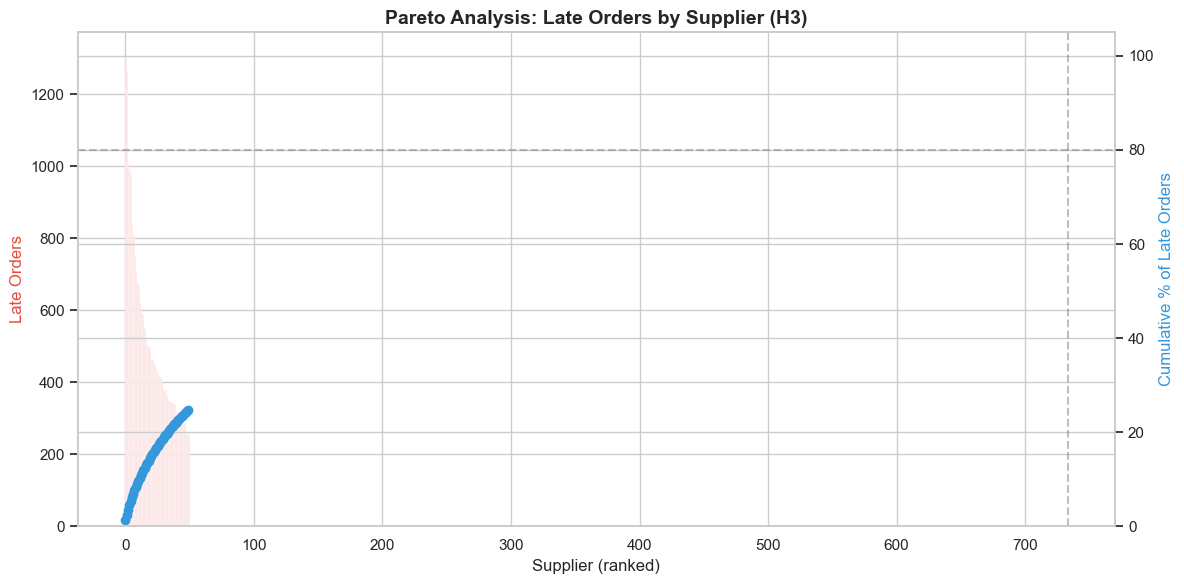

In [5]:
# === Pareto Analysis: Do 20% of suppliers cause 80% of delays? (H3) ===
supplier_delays = df.groupby('supplier_proxy').agg(
    total_orders=('is_early_or_ontime', 'size'),
    late_orders=('is_early_or_ontime', lambda s: (1 - s.mean()) * s.count())
).reset_index()
supplier_delays = supplier_delays.sort_values('late_orders', ascending=False).reset_index(drop=True)
supplier_delays['cumulative_orders'] = supplier_delays['total_orders'].cumsum()
supplier_delays['cumulative_late'] = supplier_delays['late_orders'].cumsum()
supplier_delays['cumulative_late_pct'] = supplier_delays['cumulative_late'] / supplier_delays['late_orders'].sum() * 100
supplier_delays['supplier_pct'] = (supplier_delays.index + 1) / len(supplier_delays) * 100

pct_20 = supplier_delays[supplier_delays['supplier_pct'] <= 20]
late_from_top20 = pct_20['late_orders'].sum()
total_late = supplier_delays['late_orders'].sum()
print('=== H3: Pareto Analysis ===')
print(f'Total supplier proxies: {len(supplier_delays):,}')
print(f'Top 20% suppliers: {len(pct_20):,}')
print(f'Late orders from top 20%: {late_from_top20:,.0f} ({late_from_top20/total_late*100:.1f}% of all late orders)')
print(f'Total late orders: {total_late:,.0f}')

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(range(50), supplier_delays['late_orders'].head(50), color='#e74c3c', alpha=0.7)
ax1.set_xlabel('Supplier (ranked)')
ax1.set_ylabel('Late Orders', color='#e74c3c')

ax2 = ax1.twinx()
ax2.plot(range(50), supplier_delays['cumulative_late_pct'].head(50),
         color='#3498db', marker='o', linewidth=2)
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=len(supplier_delays)*0.2, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylabel('Cumulative % of Late Orders', color='#3498db')
ax2.set_ylim(0, 105)
ax1.set_title('Pareto Analysis: Late Orders by Supplier (H3)')
save_fig('23_pareto_suppliers')
plt.show()


=== Most Consistent Suppliers (Lowest Delay Std Dev) ===


,supplier_proxy,orders,mean_delay,std_delay,delay_range
3441,Villeurbanne | Francia,64,1.27,0.67,4.00
2223,Murcia | España,60,0.97,0.73,3.50
2312,Nieuwegein | Países Bajos,51,0.99,0.78,3.50
380,Bezerros | Brasil,102,1.09,0.78,3.50
3529,Wiesbaden | Alemania,74,1.16,0.81,4.00
850,Cárdenas | Cuba,74,-0.19,0.82,2.50
2825,Salamanca | México,56,1.31,0.82,3.50
2665,Raleigh | Estados Unidos,54,1.01,0.83,2.50
3445,Vilna | Lituania,58,0.79,0.83,4.00
3165,Tampico | México,57,0.89,0.85,3.50



=== Least Consistent Suppliers (Highest Delay Std Dev) ===


,supplier_proxy,orders,mean_delay,std_delay,delay_range
2684,Reading | Reino Unido,54,0.63,1.52,4.00
1893,London | Canada,75,0.77,1.52,4.00
1873,Lippstadt | Alemania,50,0.54,1.52,4.00
3645,Zhuhai | China,65,0.57,1.54,4.00
1973,Makati | Filipinas,52,0.22,1.54,4.00
394,Bielefeld | Alemania,70,0.61,1.55,4.00
2613,Providence | Estados Unidos,74,0.47,1.55,4.00
2206,Mougins | Francia,60,0.49,1.55,4.00
2503,Pescara | Italia,55,0.47,1.57,4.00
1037,Espoo | Finlandia,81,0.33,1.59,4.00


/var/folders/5f/v7pqtktn107_c707d8vd5jc00000gn/T/ipykernel_20350/1025033575.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_var, y='supplier_proxy', x='std_delay', palette='Reds_r', ax=ax)


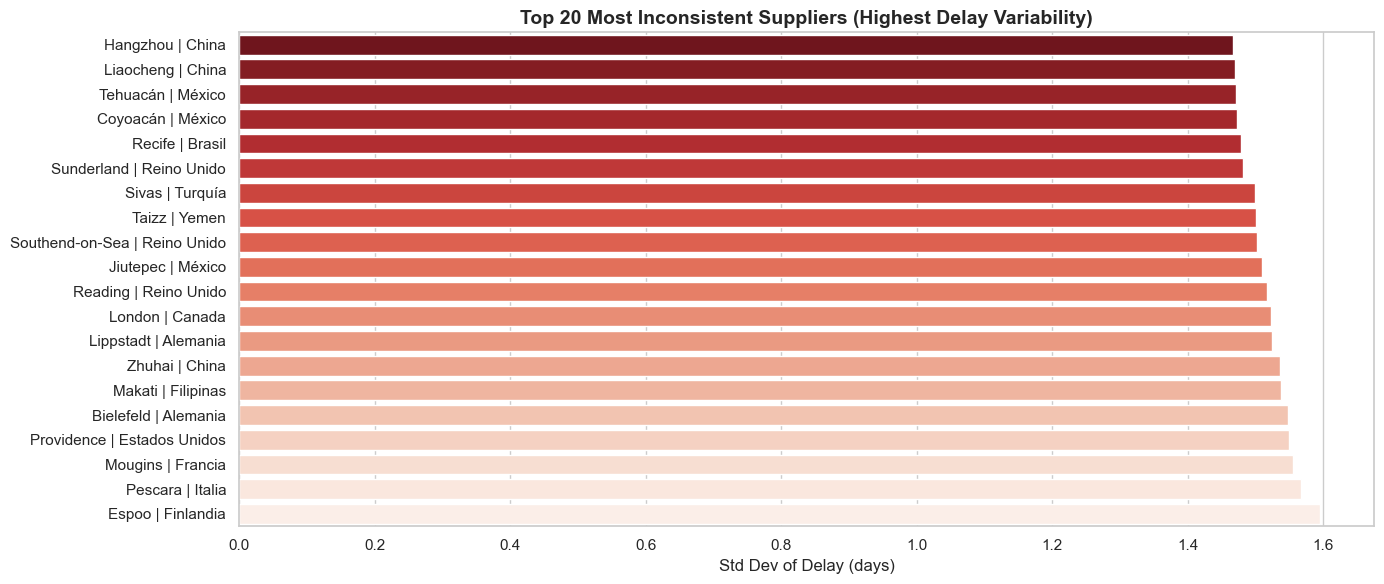

In [6]:
# === Lead Time Consistency (Best vs Worst) ===
lead_time = df.groupby('supplier_proxy').agg(
    orders=('is_early_or_ontime', 'size'),
    mean_delay=('actual_shipping_delay', 'mean'),
    std_delay=('actual_shipping_delay', 'std'),
    min_delay=('actual_shipping_delay', 'min'),
    max_delay=('actual_shipping_delay', 'max')
).reset_index()
lead_time['delay_range'] = lead_time['max_delay'] - lead_time['min_delay']
lead_time['consistency_score'] = 1 / (1 + lead_time['std_delay'])

consistent = lead_time[lead_time['orders'] >= 50].sort_values('std_delay')

print('=== Most Consistent Suppliers (Lowest Delay Std Dev) ===')
display(consistent[['supplier_proxy', 'orders', 'mean_delay', 'std_delay', 'delay_range']].head(10).round(3))

print('\n=== Least Consistent Suppliers (Highest Delay Std Dev) ===')
display(consistent[['supplier_proxy', 'orders', 'mean_delay', 'std_delay', 'delay_range']].tail(10).round(3))

fig, ax = plt.subplots(figsize=(14, 6))
top_var = consistent.tail(20)
sns.barplot(data=top_var, y='supplier_proxy', x='std_delay', palette='Reds_r', ax=ax)
ax.set_title('Top 20 Most Inconsistent Suppliers (Highest Delay Variability)')
ax.set_xlabel('Std Dev of Delay (days)')
ax.set_ylabel('')
save_fig('24_supplier_consistency')
plt.show()


In [7]:
# === Supplier Product-Level Performance ===
prod_score = df.groupby('supplier_product').agg(
    orders=('is_early_or_ontime', 'size'),
    on_time_rate=('is_early_or_ontime', 'mean'),
    avg_delay=('actual_shipping_delay', 'mean'),
    avg_profit=('order_profit_per_order', 'mean')
).reset_index()
prod_score['on_time_pct'] = prod_score['on_time_rate'] * 100

top_prod = prod_score[prod_score['orders'] >= 30].sort_values('on_time_pct', ascending=False)

print('=== Top 10 Supplier-Product Combos by On-Time Rate (30+ orders) ===')
display(top_prod[['supplier_product', 'orders', 'on_time_pct', 'avg_delay', 'avg_profit']].head(10).round(2))

print('\n=== Bottom 10 Supplier-Product Combos by On-Time Rate (30+ orders) ===')
display(top_prod[['supplier_product', 'orders', 'on_time_pct', 'avg_delay', 'avg_profit']].tail(10).round(2))


=== Top 10 Supplier-Product Combos by On-Time Rate (30+ orders) ===


,supplier_product,orders,on_time_pct,avg_delay,avg_profit
25006,Naples | Italia -> Nike Men's CJ Elite 2 TD Fo...,33,72.73,-0.27,18.83
19269,Las Tunas | Cuba -> Perfect Fitness Perfect Ri...,38,65.79,0.16,22.31
17083,Juárez | México -> Pelican Sunstream 100 Kayak,52,65.38,0.07,26.20
22722,Medellín | Colombia -> Perfect Fitness Perfect...,37,64.86,0.08,29.37
9532,Dakar | Senegal -> Perfect Fitness Perfect Rip...,31,64.52,-0.27,23.49
695,Alexandria | Egipto -> Nike Men's Dri-FIT Vict...,31,64.52,0.02,19.88
18786,La Romana | República Dominicana -> Perfect Fi...,36,63.89,0.07,15.29
13789,Guantánamo | Cuba -> Nike Men's CJ Elite 2 TD ...,33,63.64,0.11,18.11
34091,Springfield | Estados Unidos -> Nike Men's CJ ...,49,63.27,0.16,24.55
25515,Nice | Francia -> Nike Men's CJ Elite 2 TD Foo...,32,62.50,-0.06,22.64



=== Bottom 10 Supplier-Product Combos by On-Time Rate (30+ orders) ===


,supplier_product,orders,on_time_pct,avg_delay,avg_profit
39577,Yakarta | Indonesia -> Under Armour Girls' Tod...,44,25.00,0.90,24.27
27514,Perth | Australia -> Diamondback Women's Seren...,33,24.24,1.14,56.22
32449,Santiago de los Caballeros | República Dominic...,43,23.26,0.80,24.68
15316,Houston | Estados Unidos -> O'Brien Men's Neop...,86,23.26,0.85,15.97
18629,La Ceiba | Honduras -> O'Brien Men's Neoprene ...,35,22.86,0.84,22.43
30061,Richmond | Estados Unidos -> O'Brien Men's Neo...,31,22.58,1.13,25.33
10674,Duisburg | Alemania -> Field & Stream Sportsma...,31,22.58,0.81,83.11
1518,Apopa | El Salvador -> Field & Stream Sportsma...,37,21.62,0.99,57.66
30169,Riyadh | Arabia Saudí -> Field & Stream Sports...,37,21.62,0.91,73.14
22443,Matagalpa | Nicaragua -> Nike Men's CJ Elite 2...,30,20.00,1.27,23.53


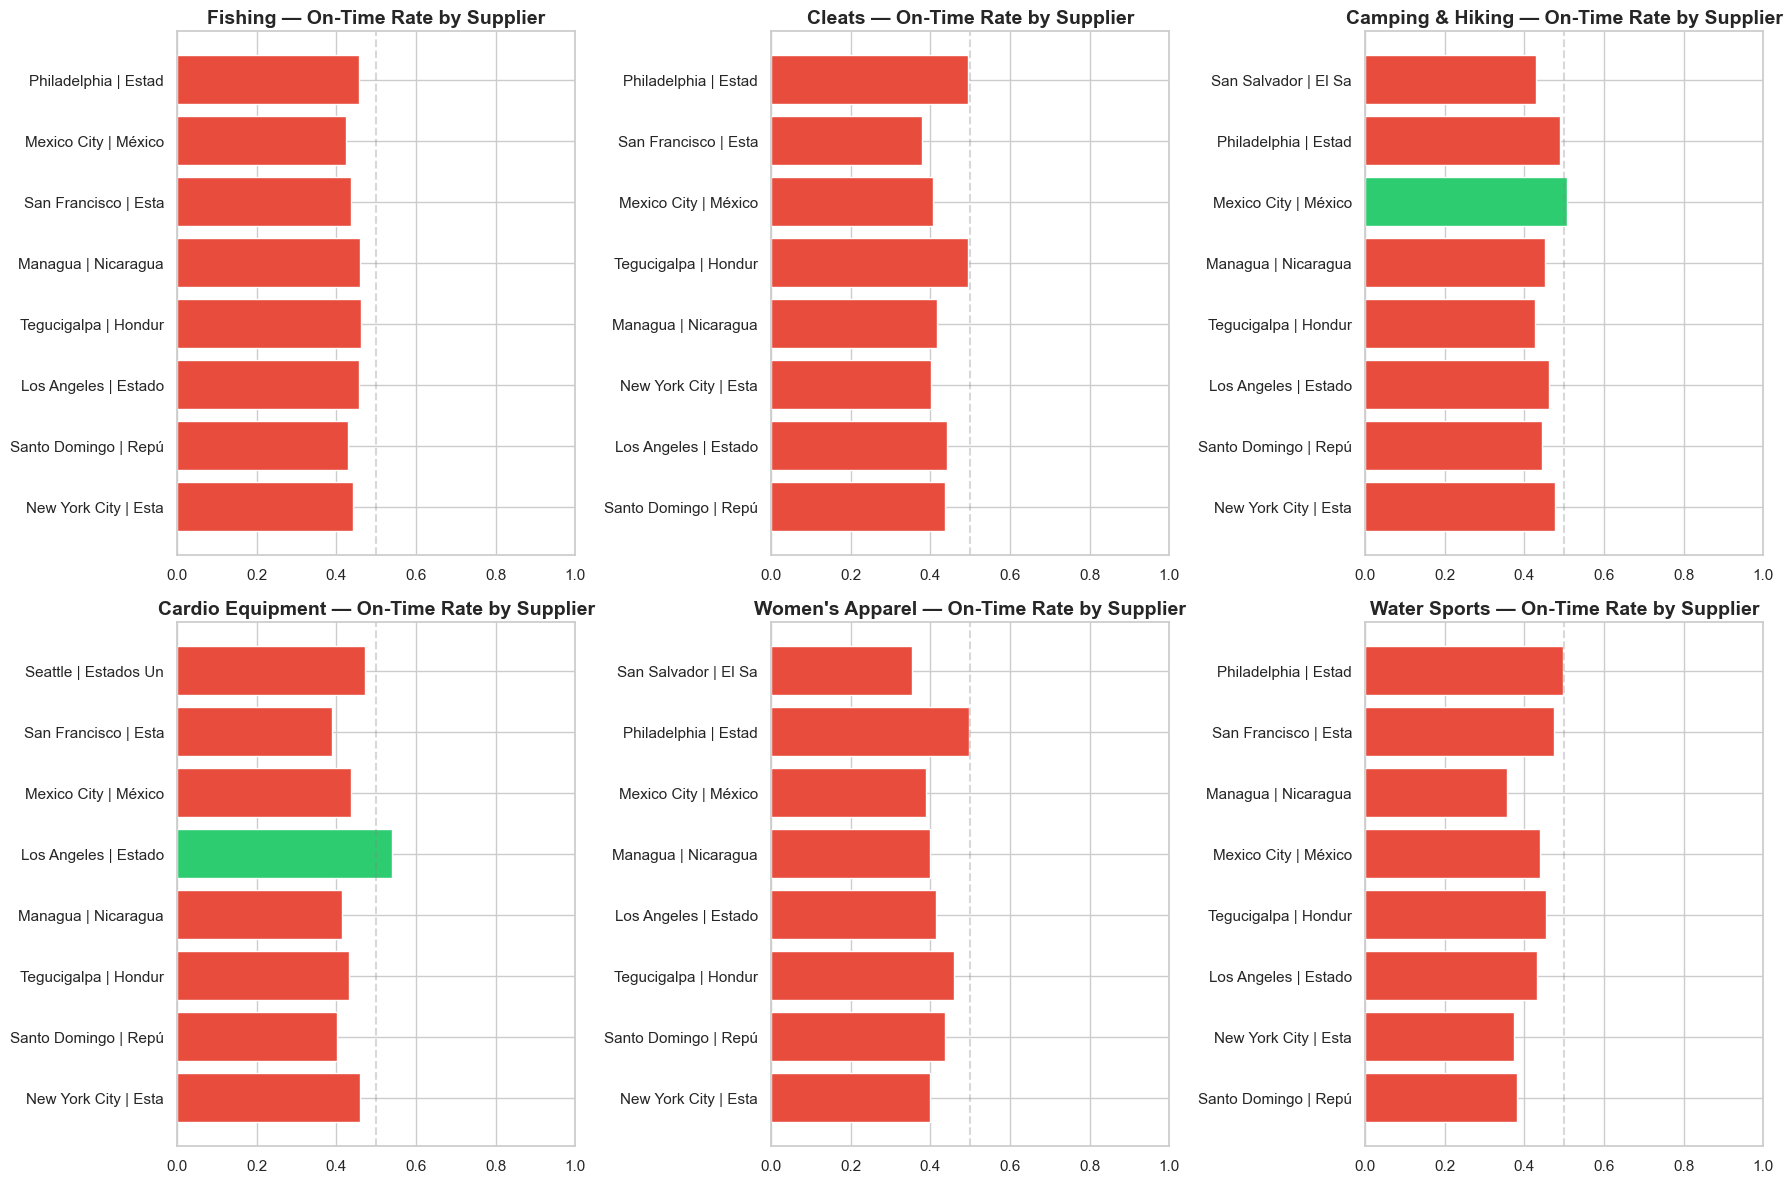

In [8]:
# === Supplier Performance by Product Category ===
cat_supplier = df.groupby(['category_name', 'supplier_proxy']).agg(
    orders=('is_early_or_ontime', 'size'),
    on_time_rate=('is_early_or_ontime', 'mean'),
    avg_delay=('actual_shipping_delay', 'mean')
).reset_index()

top_cats = df.groupby('category_name')['sales'].sum().nlargest(6).index
cat_supplier_top = cat_supplier[cat_supplier['category_name'].isin(top_cats)]
cat_supplier_top = cat_supplier_top[cat_supplier_top['orders'] >= 30]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, cat in zip(axes.flatten(), top_cats):
    subset = cat_supplier_top[cat_supplier_top['category_name'] == cat].nlargest(8, 'orders')
    if len(subset) > 0:
        colors = ['#2ecc71' if r >= 0.5 else '#e74c3c' for r in subset['on_time_rate']]
        ax.barh(subset['supplier_proxy'].str[:20], subset['on_time_rate'], color=colors)
        ax.set_title(f'{cat} — On-Time Rate by Supplier')
        ax.set_xlim(0, 1)
        ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.3)
    else:
        ax.set_visible(False)
plt.tight_layout()
save_fig('25_supplier_by_category')
plt.show()


=== Top 10 Highest Risk Products ===


,product_name,orders,on_time_rate,avg_delay,risk_score
76,SOLE E25 Elliptical,10,0.30,0.95,86.72
29,Garmin Approach S4 Golf GPS Watch,36,0.33,0.85,76.73
19,Diamondback Boys' Insight 24 Performance Hybr,29,0.34,0.60,75.26
60,Nike Men's Fingertrap Max Training Shoe,64,0.39,0.81,75.26
93,Titleist Club Glove Travel Cover,34,0.35,0.81,75.05
68,Ogio Race Golf Shoes,61,0.31,0.71,74.23
84,TaylorMade White Smoke IN-12 Putter,63,0.41,0.70,73.87
115,adidas Men's Germany Black Crest Away Tee,289,0.36,0.71,73.59
98,Titleist Small Wheeled Travel Cover,54,0.35,0.75,73.19
53,Mio ALPHA Heart Rate Monitor/Sport Watch,67,0.37,0.65,72.82



=== Top 10 Lowest Risk Products ===


,product_name,orders,on_time_rate,avg_delay,risk_score
77,SOLE E35 Elliptical,15,0.60,0.23,47.78
85,TaylorMade Women's RBZ SL Rescue,68,0.54,0.21,48.07
20,Diamondback Girls' Clarity 24 Hybrid Bike 201,28,0.50,0.12,49.86
51,Merrell Women's Grassbow Sport Waterproof Hik,58,0.53,0.25,52.95
52,Merrell Women's Siren Mid Waterproof Hiking B,70,0.50,0.25,54.58
42,LIJA Women's Argyle Golf Polo,66,0.50,0.32,56.46
80,Stiga Master Series ST3100 Competition Indoor,27,0.48,0.28,56.78
63,Nike Men's Kobe IX Elite Low Basketball Shoe,63,0.46,0.39,56.85
117,insta-bed Neverflat Air Mattress,60,0.50,0.35,56.90
49,Merrell Men's All Out Flash Trail Running Sho,85,0.49,0.35,58.13


/var/folders/5f/v7pqtktn107_c707d8vd5jc00000gn/T/ipykernel_20350/3692921050.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_plot, y='product_name', x='risk_score', palette='RdYlGn_r', ax=ax)


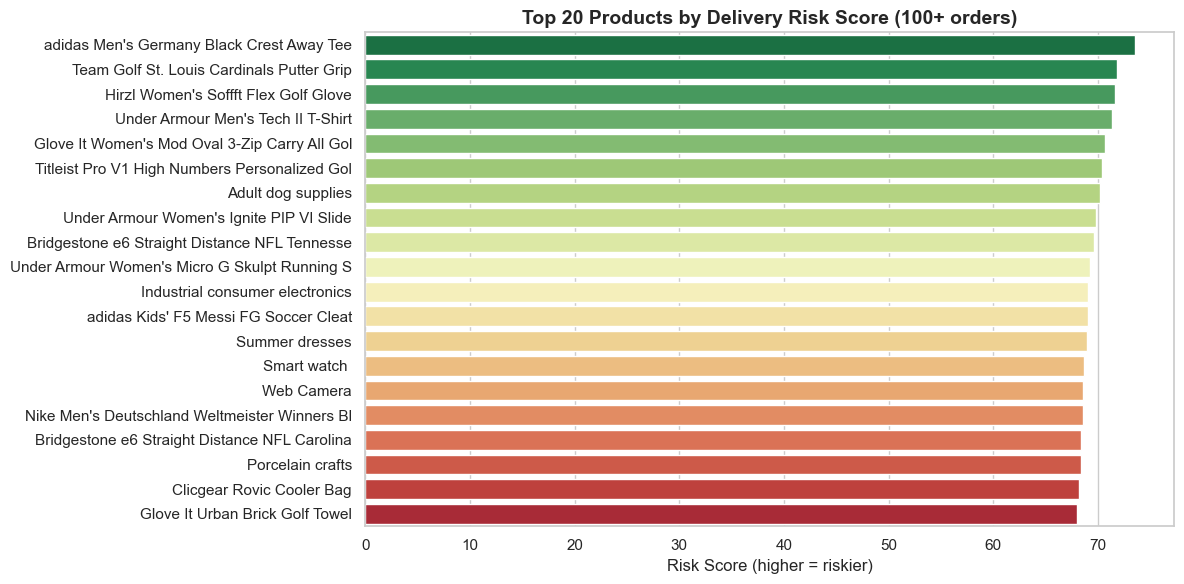

In [9]:
# === Product Risk Scoring ===
prod_risk = df.groupby('product_name').agg(
    orders=('is_early_or_ontime', 'size'),
    on_time_rate=('is_early_or_ontime', 'mean'),
    avg_delay=('actual_shipping_delay', 'mean'),
    delay_std=('actual_shipping_delay', 'std'),
    total_sales=('sales', 'sum'),
    total_profit=('order_profit_per_order', 'sum')
).reset_index()
prod_risk['risk_score'] = (
    (1 - prod_risk['on_time_rate']) * 40 +
    (prod_risk['avg_delay'].clip(0) / prod_risk['avg_delay'].max()) * 30 +
    (prod_risk['delay_std'] / prod_risk['delay_std'].max()) * 30
)

high_risk = prod_risk.nlargest(10, 'risk_score')
low_risk = prod_risk.nsmallest(10, 'risk_score')

print('=== Top 10 Highest Risk Products ===')
display(high_risk[['product_name', 'orders', 'on_time_rate', 'avg_delay', 'risk_score']].round(3))

print('\n=== Top 10 Lowest Risk Products ===')
display(low_risk[['product_name', 'orders', 'on_time_rate', 'avg_delay', 'risk_score']].round(3))

fig, ax = plt.subplots(figsize=(12, 6))
risk_plot = prod_risk[prod_risk['orders'] >= 100].sort_values('risk_score', ascending=False).head(20)
sns.barplot(data=risk_plot, y='product_name', x='risk_score', palette='RdYlGn_r', ax=ax)
ax.set_title('Top 20 Products by Delivery Risk Score (100+ orders)')
ax.set_xlabel('Risk Score (higher = riskier)')
ax.set_ylabel('')
save_fig('26_product_risk')
plt.show()


In [10]:
print('=' * 60)
print('SUPPLIER PERFORMANCE KEY FINDINGS')
print('=' * 60)

print(f'\nSupplier proxies (city|country): {df["supplier_proxy"].nunique():,}')
print(f'Supplier-product combos: {df["supplier_product"].nunique():,}')
print(f'Active suppliers (50+ orders): {len(active):,}')

# H3 result
print(f'\n=== H3: PARETO RESULT ===')
print(f'Top 20% of suppliers cause {late_from_top20/total_late*100:.1f}% of late orders')
if late_from_top20/total_late*100 >= 70:
    print('Result: CONFIRMED — Pareto principle applies')
elif late_from_top20/total_late*100 >= 50:
    print('Result: PARTIAL — Concentration exists but weaker than 80/20')
else:
    print('Result: NOT CONFIRMED — Late orders are broadly distributed')

best_supplier = active.iloc[0]['supplier_proxy']
worst_supplier = active.iloc[-1]['supplier_proxy']
print(f'\nMost reliable supplier: {best_supplier} (score: {active.iloc[0]["reliability_score"]:.1f})')
print(f'Least reliable supplier: {worst_supplier} (score: {active.iloc[-1]["reliability_score"]:.1f})')

print(f'\nTotal products scored for risk: {len(prod_risk)}')
print(f'High-risk products (top 10%): {len(high_risk)}')
print(f'Low-risk products: {len(low_risk)}')


SUPPLIER PERFORMANCE KEY FINDINGS

Supplier proxies (city|country): 3,665
Supplier-product combos: 40,298
Active suppliers (50+ orders): 820

=== H3: PARETO RESULT ===
Top 20% of suppliers cause 71.0% of late orders
Result: CONFIRMED — Pareto principle applies

Most reliable supplier: Cárdenas | Cuba (score: 69.4)
Least reliable supplier: Villeurbanne | Francia (score: 28.2)

Total products scored for risk: 118
High-risk products (top 10%): 10
Low-risk products: 10


In [11]:
# === Operational Recommendations ===
print('=' * 60)
print('RECOMMENDATIONS')
print('=' * 60)

# From Pareto analysis
if late_from_top20/total_late*100 >= 50:
    print(f'\n1. Focus on top 20% suppliers — they drive {late_from_top20/total_late*100:.0f}% of delays.')
    print('   Conduct root-cause reviews with these origins.'),

# From reliability scoring
print(f'\n2. Replicate processes from reliable suppliers like {best_supplier}.')
print('   Consider preferential contracting for top-scoring origins.')

# From risk scoring
risk_names = high_risk['product_name'].head(3).tolist()
print(f'\n3. Flag high-risk products for expedited handling:')
for name in risk_names:
    print(f'   - {name}')

print(f'\n4. Diversify supplier base for inconsistent origins (top 10 by delay std dev).')
print(f'5. Set service-level agreements (SLAs) with minimum on-time targets.')


RECOMMENDATIONS

1. Focus on top 20% suppliers — they drive 71% of delays.
   Conduct root-cause reviews with these origins.

2. Replicate processes from reliable suppliers like Cárdenas | Cuba.
   Consider preferential contracting for top-scoring origins.

3. Flag high-risk products for expedited handling:
   - SOLE E25 Elliptical
   - Garmin Approach S4 Golf GPS Watch
   - Diamondback Boys' Insight 24 Performance Hybr

4. Diversify supplier base for inconsistent origins (top 10 by delay std dev).
5. Set service-level agreements (SLAs) with minimum on-time targets.
